In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

IMPORTING DATASETS

In [2]:
data_log2 = pd.read_pickle('data_log2_Coimbra_threshold.pkl')

In [3]:
data_log2 

Protein.Group,A0A075B6H7,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A0A0MRZ8;P04433,A0A0A0MS15,A0A0B4J1U7,A0A0B4J1X8,A0A0B4J1Y9,A0A0B4J2B5,...,Q9NYQ8,Q9P121,Q9P2S2,Q9UBP4,Q9UBX5,Q9UKI9;P09086;P14859,Q9ULB1,Q9Y4C0,Q9Y646,Q9Y6R7
109094,10.707256,5.411257,10.023893,7.638458,9.985671,5.338670,7.244240,9.311739,9.095131,10.772999,...,4.290432,8.415112,6.759808,11.329084,6.049101,9.030046,6.976387,7.458193,6.139852,6.967906
103208,10.510289,4.121894,9.891121,6.968736,9.974615,6.571228,6.063140,8.986320,8.741339,11.256226,...,4.580694,8.203358,6.722548,11.352380,6.357804,10.300444,6.761179,7.385923,6.398954,7.078834
106086,10.989870,5.323903,10.223121,7.522158,10.246075,6.168520,6.770049,9.322539,9.478424,11.403204,...,4.759955,8.712379,6.741656,11.591747,6.424029,9.908852,7.325251,7.835930,6.582637,7.505629
105634,11.706315,6.707000,11.341958,8.700062,11.423557,7.464734,5.915024,9.812152,9.418742,12.369186,...,4.100952,8.368140,6.500428,11.666797,6.222213,10.495495,6.355367,7.287186,6.226406,6.764420
106008,10.733066,4.704031,10.645001,8.005720,10.433419,5.200661,8.202614,9.718603,9.274483,11.513303,...,4.073829,8.467292,6.067114,11.768011,6.594716,10.377319,7.064355,7.343239,6.230420,7.659339
110203,10.245838,4.292936,9.241104,7.304219,10.118993,6.080417,8.769074,9.116656,8.588032,10.729825,...,5.029488,8.565658,6.868131,11.799646,6.323964,9.477698,7.183040,7.686171,6.173755,7.017710
108382,11.131838,5.668079,10.281976,7.698288,9.901271,6.452478,9.130254,9.069530,9.252261,11.197180,...,3.923415,8.317399,6.656554,11.519843,6.304646,10.041673,6.712032,7.335998,6.424015,7.993810
104968,10.706228,5.402255,10.087489,7.788953,9.729106,6.248379,8.236249,9.583534,8.581683,11.398770,...,4.286970,8.294180,6.557016,11.373409,5.980238,9.407812,6.957938,7.421526,6.570718,8.275324
107018,10.330312,5.685836,10.257482,7.405022,10.142733,6.457701,8.621645,9.630560,9.432364,11.696972,...,3.918405,8.469768,6.735170,11.248604,6.273708,10.364966,6.913189,7.510329,5.884200,6.478033
109456,9.491047,2.964088,8.829406,6.604319,9.283452,4.231041,4.319119,8.628099,7.791254,10.291482,...,4.311648,8.384715,6.565285,11.583666,6.443028,9.050121,7.160134,7.625658,6.226703,6.323552


In [4]:
import pickle

with open('list_groups_Coimbra.pkl', 'rb') as f:
    list_groups = pickle.load(f)

print(list_groups)

['MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD']


In [5]:
list_groups = pd.Series(list_groups)

APPLYING A SIMPLE RANDOM FOREST

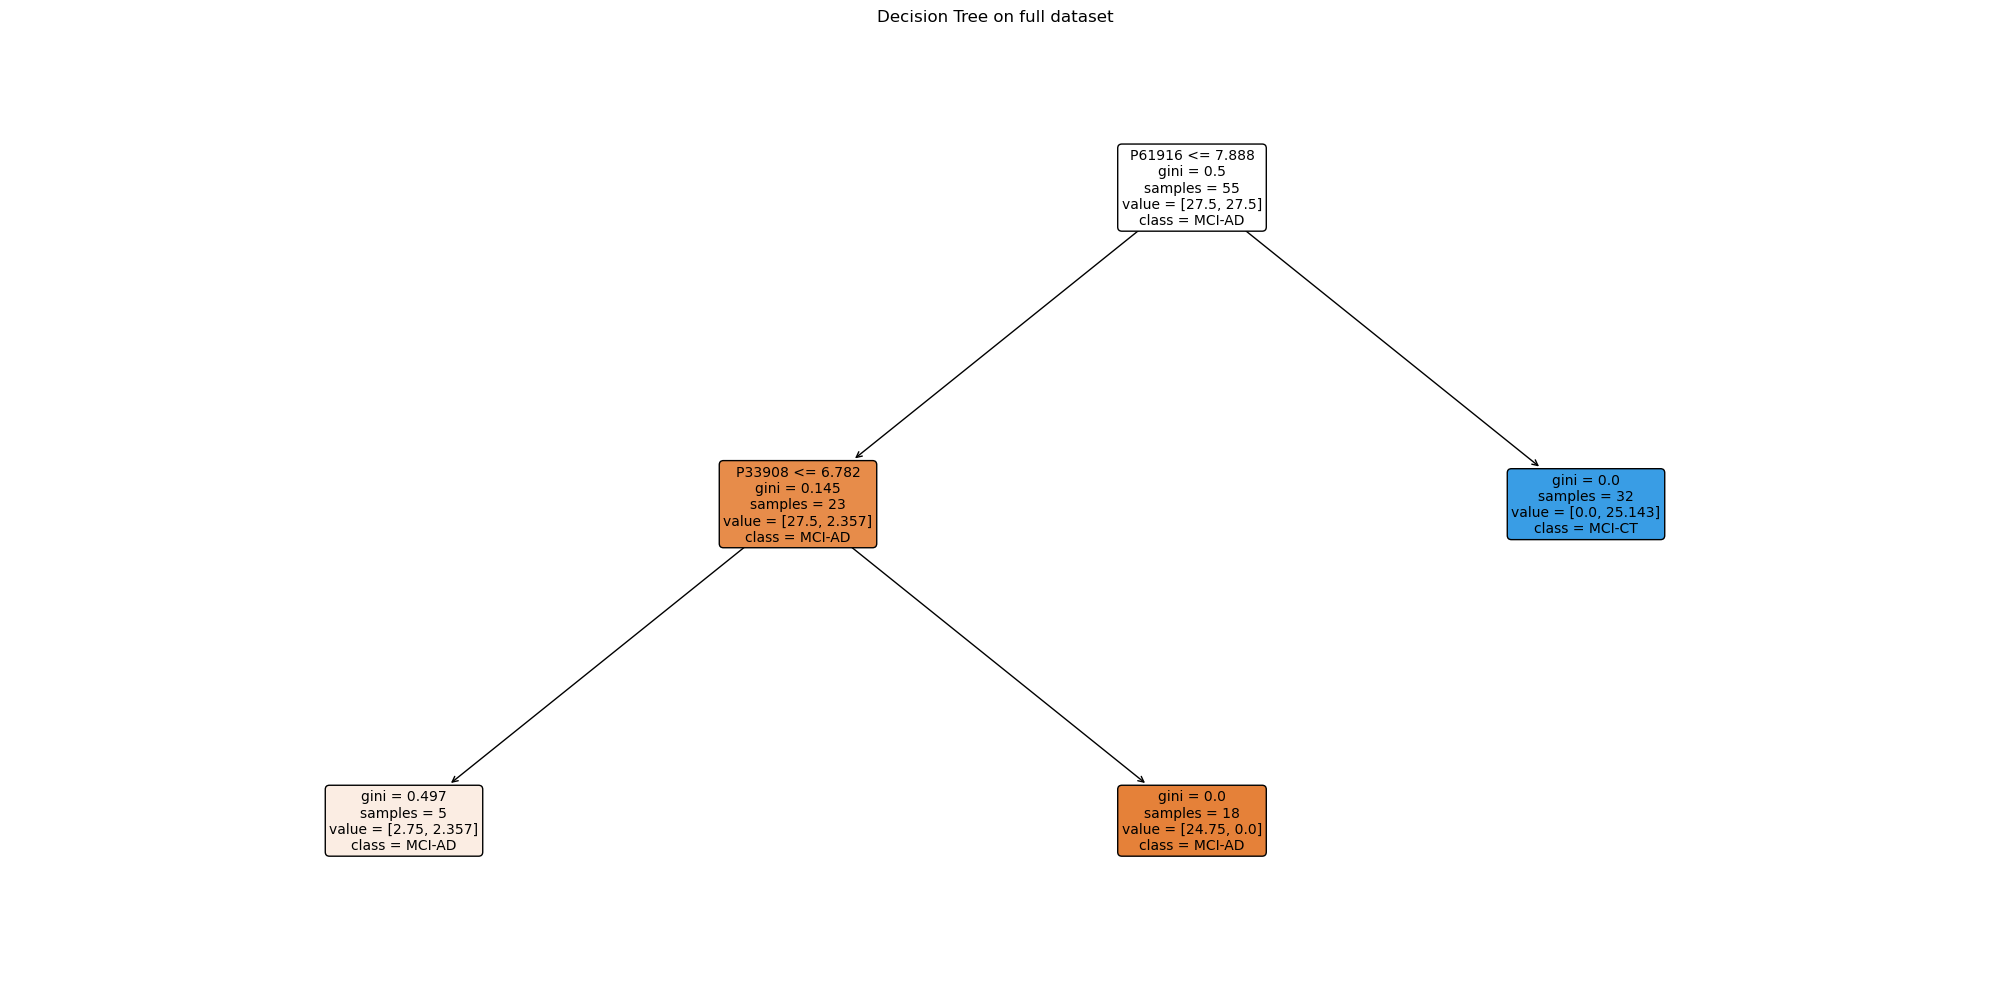


Decision Rules:

|--- P61916 <= 7.89
|   |--- P33908 <= 6.78
|   |   |--- class: MCI-AD
|   |--- P33908 >  6.78
|   |   |--- class: MCI-AD
|--- P61916 >  7.89
|   |--- class: MCI-CT



In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# ======================
# DATA
# ======================
X = data_log2.copy()
y = np.array(list_groups)

# ======================
# MODELLO SEMPLICE
# ======================
dt = DecisionTreeClassifier(
    max_depth=3,          # fondamentale per leggibilità
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=0
)

dt.fit(X, y)

# ======================
# PLOT ALBERO
# ======================
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree on full dataset")
plt.tight_layout()
plt.savefig("simple_tree_Coimbra.png", dpi=300, bbox_inches='tight')
plt.show()

# ======================
# REGOLE TESTUALI
# ======================
print("\nDecision Rules:\n")
rules = export_text(dt, feature_names=list(X.columns))
print(rules)

RANDOM FOREST

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, roc_auc_score

# ======================
# DATI
# ======================
X = data_log2.copy()
y = np.array(list_groups)

# binarizza per AUC (importante!)
y_binary = (y == "MCI-AD").astype(int)

# ======================
# PARAMETRI GLOBALI
# ======================
thresholds = [ 0.7, 0.8, 0.9]
n_iterations = 20
seeds = range(15)

# ======================
# STORAGE
# ======================
all_results = []
feature_counter = {}
threshold_counter = {}

# ======================
# BOOTSTRAP
# ======================
def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]

    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)

    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)

    return X.iloc[indices], y[indices]


# ======================
# LOOP SEED
# ======================
union_top_features = set()

for seed in seeds:

    print(f"\n===== SEED {seed} =====")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=seed
    )

    y_train_bin = (y_train == "MCI-AD").astype(int)
    y_test_bin = (y_test == "MCI-AD").astype(int)

    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=seed)

    threshold_scores = []

    # ======================
    # CV per scegliere threshold
    # ======================
    for t in thresholds:

        fold_scores = []

        for train_idx, val_idx in cv.split(X_train, y_train):

            X_subtrain = X_train.iloc[train_idx]
            y_subtrain = y_train[train_idx]

            X_val = X_train.iloc[val_idx]
            y_val = y_train[val_idx]

            y_val_bin = (y_val == "MCI-AD").astype(int)

            # ===== bootstrap importance
            feature_names = X_subtrain.columns
            importance_matrix = np.zeros((n_iterations, len(feature_names)))

            for i in range(n_iterations):

                X_boot, y_boot = stratified_bootstrap(X_subtrain, y_subtrain)

                rf = RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=seed
                )

                rf.fit(X_boot, y_boot)
                importance_matrix[i] = rf.feature_importances_

            mean_importance = importance_matrix.mean(axis=0)

            ranking_df = pd.DataFrame({
                "protein": feature_names,
                "importance": mean_importance
            }).sort_values("importance", ascending=False)

            # normalizzazione
            ranking_df["importance"] /= ranking_df["importance"].sum()
            ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

            # selezione feature
            selected_features = ranking_df[
                ranking_df["cum_importance"] <= t
            ]["protein"]

            if len(selected_features) == 0:
                selected_features = ranking_df["protein"].iloc[:1]

            # train modello
            rf = RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=seed
            )

            rf.fit(X_subtrain[selected_features], y_subtrain)

            # valutazione
            y_pred = rf.predict(X_val[selected_features])
            mcc = matthews_corrcoef(y_val, y_pred)

            fold_scores.append(mcc)

        threshold_scores.append(np.mean(fold_scores))

    # ======================
    # best threshold
    # ======================
    best_threshold = thresholds[np.argmax(threshold_scores)]
    print("Best threshold:", best_threshold)

    # ======================
    # TRAIN FINALE (su tutto train)
    # ======================
    feature_names = X_train.columns
    importance_matrix = np.zeros((n_iterations, len(feature_names)))

    for i in range(n_iterations):

        X_boot, y_boot = stratified_bootstrap(X_train, y_train)

        rf = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            n_jobs=-1,
            random_state=i
        )

        rf.fit(X_boot, y_boot)
        importance_matrix[i] = rf.feature_importances_

    mean_importance = importance_matrix.mean(axis=0)

    ranking_df = pd.DataFrame({
        "protein": feature_names,
        "importance": mean_importance
    }).sort_values("importance", ascending=False)

    ranking_df["importance"] /= ranking_df["importance"].sum()
    ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

    top_features = ranking_df[
        ranking_df["cum_importance"] <= best_threshold
    ]["protein"]

    union_top_features.update(top_features)

    if len(top_features) == 0:
        top_features = ranking_df["protein"].iloc[:1]

    print("Numero feature:", len(top_features))

    # ======================
    # TEST
    # ======================
    rf_final = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    )

    rf_final.fit(X_train[top_features], y_train)

    y_pred = rf_final.predict(X_test[top_features])
    class_order = rf_final.classes_
    ad_index = np.where(class_order == "MCI-AD")[0][0]
    
    y_prob = rf_final.predict_proba(X_test[top_features])[:, ad_index]

    test_mcc = matthews_corrcoef(y_test, y_pred)
    test_auc = roc_auc_score(y_test_bin, y_prob)
    print("Class order:", rf_final.classes_)
    print("Test MCC:", test_mcc)
    print("Test AUC:", test_auc)

    # ======================
    # SALVATAGGIO
    # ======================
    all_results.append({
        "model": "RF",
        "seed": seed,
        "mcc": test_mcc,
        "auc": test_auc,
        "n_features": len(top_features),
        "best_threshold": best_threshold
    })

    # frequenza feature
    for f in top_features:
        feature_counter[f] = feature_counter.get(f, 0) + 1

    # frequenza threshold
    threshold_counter[best_threshold] = threshold_counter.get(best_threshold, 0) + 1


# ======================
# RISULTATI FINALI
# ======================
df_results = pd.DataFrame(all_results)

print("\n===== FINAL RESULTS =====")
print("Mean MCC:", df_results["mcc"].mean())
print("Mean AUC:", df_results["auc"].mean())

# frequenze
feature_freq = pd.Series(feature_counter).sort_values(ascending=False) / len(seeds)
threshold_freq = pd.Series(threshold_counter).sort_index() / len(seeds)

print("\nTop features (frequency):")
print(feature_freq.head(20))

print("\nThreshold frequency:")
print(threshold_freq)
print("\n===== UNIONE DI TUTTE LE TOP FEATURES =====")
print(f"Numero totale di proteine uniche trovate tra tutti i seed: {len(union_top_features)}")
print("Lista completa:")
print(sorted(list(union_top_features)))


===== SEED 0 =====
Best threshold: 0.7
Numero feature: 45
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.8740073734751262
Test AUC: 1.0

===== SEED 1 =====
Best threshold: 0.7
Numero feature: 43
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 1.0
Test AUC: 1.0

===== SEED 2 =====
Best threshold: 0.7
Numero feature: 43
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.8740073734751262
Test AUC: 1.0

===== SEED 3 =====
Best threshold: 0.7
Numero feature: 43
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 1.0
Test AUC: 1.0

===== SEED 4 =====
Best threshold: 0.7
Numero feature: 41
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 1.0
Test AUC: 1.0

===== SEED 5 =====
Best threshold: 0.7
Numero feature: 44
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 1.0
Test AUC: 1.0

===== SEED 6 =====
Best threshold: 0.9
Numero feature: 107
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.8740073734751262
Test AUC: 1.0

===== SEED 7 =====
Best threshold: 0.7
Numero feature: 45
Class order: ['MCI-AD' 'MCI-CT']
Test MCC: 0.8740073734

In [8]:
feature_freq.to_pickle('feature_rf_Coimbra_threshold.pkl')
df_results = pd.DataFrame(all_results)
df_results.to_pickle('results_Coimbra_rf_threshold.pkl')
len(feature_freq)

132

In [9]:
feature_freq.head(10)

P02751    1.0
P18065    1.0
P61916    1.0
Q12805    1.0
Q16270    1.0
Q9UBX5    1.0
P07998    1.0
Q92876    1.0
P23142    1.0
P49641    1.0
dtype: float64

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, roc_auc_score

# ======================
# DATI
# ======================
X = data_log2.copy()
y = np.array(list_groups)
y_binary = (y == "MCI-AD").astype(int)

# ======================
# PARAMETRI
# ======================
thresholds = [0.7, 0.8, 0.9]
n_iterations = 20
n_splits = 5

# ======================
# BOOTSTRAP
# ======================
def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]

    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)

    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)

    return X.iloc[indices], y[indices]

# ======================
# CV
# ======================
cv = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.3, random_state=42)

threshold_scores = []

# ======================
# SCELTA THRESHOLD (CV)
# ======================
for t in thresholds:

    fold_mcc = []
    fold_auc = []

    for train_idx, val_idx in cv.split(X, y):

        X_sub = X.iloc[train_idx]
        y_sub = y[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y[val_idx]
        y_val_bin = (y_val == "MCI-AD").astype(int)

        # ===== bootstrap importance
        feature_names = X_sub.columns
        importance_matrix = np.zeros((n_iterations, len(feature_names)))

        for i in range(n_iterations):
            X_boot, y_boot = stratified_bootstrap(X_sub, y_sub)

            rf = RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                n_jobs=-1,
                random_state=i
            )

            rf.fit(X_boot, y_boot)
            importance_matrix[i] = rf.feature_importances_

        mean_importance = importance_matrix.mean(axis=0)

        ranking_df = pd.DataFrame({
            "protein": feature_names,
            "importance": mean_importance
        }).sort_values("importance", ascending=False)

        ranking_df["importance"] /= ranking_df["importance"].sum()
        ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

        selected_features = ranking_df[
            ranking_df["cum_importance"] <= t
        ]["protein"]

        if len(selected_features) == 0:
            selected_features = ranking_df["protein"].iloc[:1]

        # modello
        rf_model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        )

        rf_model.fit(X_sub[selected_features], y_sub)

        y_pred = rf_model.predict(X_val[selected_features])

        # ✅ FIX AUC
        class_order = rf_model.classes_
        ad_index = np.where(class_order == "MCI-AD")[0][0]
        y_prob = rf_model.predict_proba(X_val[selected_features])[:, ad_index]

        fold_mcc.append(matthews_corrcoef(y_val, y_pred))
        fold_auc.append(roc_auc_score(y_val_bin, y_prob))

    threshold_scores.append(np.mean(fold_mcc))

# ======================
# BEST THRESHOLD
# ======================
best_threshold = thresholds[np.argmax(threshold_scores)]
print("Best threshold:", best_threshold)

# ======================
# PERFORMANCE FINALE (CV)
# ======================
all_mcc = []
all_auc = []

# ✅ FREQUENZA FEATURE
feature_counts = pd.Series(0, index=X.columns)

for train_idx, val_idx in cv.split(X, y):

    X_sub = X.iloc[train_idx]
    y_sub = y[train_idx]

    X_val = X.iloc[val_idx]
    y_val = y[val_idx]
    y_val_bin = (y_val == "MCI-AD").astype(int)

    # bootstrap importance
    importance_matrix = np.zeros((n_iterations, X.shape[1]))

    for i in range(n_iterations):
        X_boot, y_boot = stratified_bootstrap(X_sub, y_sub)

        rf = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            n_jobs=-1,
            random_state=i
        )

        rf.fit(X_boot, y_boot)
        importance_matrix[i] = rf.feature_importances_

    mean_importance = importance_matrix.mean(axis=0)

    ranking_df = pd.DataFrame({
        "protein": X.columns,
        "importance": mean_importance
    }).sort_values("importance", ascending=False)

    ranking_df["importance"] /= ranking_df["importance"].sum()
    ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

    selected_features = ranking_df[
        ranking_df["cum_importance"] <= best_threshold
    ]["protein"]

    if len(selected_features) == 0:
        selected_features = ranking_df["protein"].iloc[:1]

    # ✅ conteggio frequenza
    feature_counts[selected_features] += 1

    rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )

    rf_model.fit(X_sub[selected_features], y_sub)

    y_pred = rf_model.predict(X_val[selected_features])

    # ✅ FIX AUC
    class_order = rf_model.classes_
    ad_index = np.where(class_order == "MCI-AD")[0][0]
    y_prob = rf_model.predict_proba(X_val[selected_features])[:, ad_index]

    all_mcc.append(matthews_corrcoef(y_val, y_pred))
    all_auc.append(roc_auc_score(y_val_bin, y_prob))

# ======================
# METRICHE FINALI
# ======================
print("\n=== VALIDATION PERFORMANCE ===")
print(f"MCC: {np.mean(all_mcc):.4f} ± {np.std(all_mcc):.4f}")
print(f"AUC: {np.mean(all_auc):.4f} ± {np.std(all_auc):.4f}")

# ======================
# FREQUENZA FEATURE
# ======================
feature_freq = (feature_counts / n_splits).sort_values(ascending=False)

print("\n=== FEATURE SELECTION FREQUENCY ===")
print(feature_freq)

# ======================
# FEATURE IMPORTANCE FINALE
# ======================
importance_matrix = np.zeros((n_iterations, X.shape[1]))

for i in range(n_iterations):
    X_boot, y_boot = stratified_bootstrap(X, y)

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        n_jobs=-1,
        random_state=i
    )

    rf.fit(X_boot, y_boot)
    importance_matrix[i] = rf.feature_importances_

mean_importance = importance_matrix.mean(axis=0)

ranking_df = pd.DataFrame({
    "protein": X.columns,
    "importance": mean_importance
}).sort_values("importance", ascending=False)

ranking_df["importance"] /= ranking_df["importance"].sum()
ranking_df["cum_importance"] = ranking_df["importance"].cumsum()

print("\n=== GLOBAL RF RANKING ===")
print(ranking_df)

# salva
ranking_df.to_csv("rf_global_ranking.csv", index=False)
feature_freq.to_csv("rf_feature_frequency.csv")

Best threshold: 0.7

=== VALIDATION PERFORMANCE ===
MCC: 0.9748 ± 0.0504
AUC: 1.0000 ± 0.0000

=== FEATURE SELECTION FREQUENCY ===
Protein.Group
Q16270    1.0
Q92876    1.0
P23142    1.0
P08123    1.0
P07998    1.0
         ... 
P05060    0.0
P05154    0.0
P05452    0.0
P05543    0.0
Q9Y6R7    0.0
Length: 237, dtype: float64

=== GLOBAL RF RANKING ===
        protein  importance  cum_importance
177      P61916    0.054769        0.054769
70       P02751    0.046415        0.101184
199      Q16270    0.038042        0.139226
139      P18065    0.037858        0.177084
68       P02749    0.037837        0.214922
..          ...         ...             ...
99       P06681    0.000273        0.999072
220      Q96PD5    0.000260        0.999333
0    A0A075B6H7    0.000252        0.999585
158      P35858    0.000228        0.999813
56       P01871    0.000187        1.000000

[237 rows x 3 columns]


In [11]:
feature_freq.to_pickle('feature_2_rf_Coimbra_threshold.pkl')